# IEM creativity tilt

The tilted density re-weights the prior: $q_\lambda(x) \propto p(x) \cdot \exp(\lambda \cdot \mathbb{E}_{x' \sim p}[D(x', x)])$, concentrating mass on points that are far from the observed distribution.

In [7]:
import sys, math, torch, matplotlib.pyplot as plt
sys.path.insert(0, '.')
from creativity_measure import *
dtype = torch.float64
torch.set_default_dtype(dtype)

## Swiss Roll with a hole

In [12]:
# Swiss Roll with a hole — the dataset for all experiments below.
from sklearn.datasets import make_swiss_roll
from sklearn.mixture import GaussianMixture

D = 2
N_SAMPLES_HOLE = 5000
N_COMPONENTS_HOLE = 24
T_HOLE_MIN, T_HOLE_MAX = 8.5, 9.5    # gap in the middle wrap (t ∈ [1.5π, 4.5π] ≈ [4.7, 14.1])

X_np2, t_np2 = make_swiss_roll(n_samples=N_SAMPLES_HOLE, noise=0.0, random_state=42)
X2d_np2 = X_np2[:, [0, 2]]

keep = ~((t_np2 >= T_HOLE_MIN) & (t_np2 <= T_HOLE_MAX))
X_kept = X2d_np2[keep]
X_hole = X2d_np2[~keep]

gmm2 = GaussianMixture(n_components=N_COMPONENTS_HOLE, covariance_type='spherical',
                       random_state=42).fit(X_kept)

MEANS        = torch.tensor(gmm2.means_,       dtype=dtype)
VARS         = torch.tensor(gmm2.covariances_, dtype=dtype)
LOG_WEIGHTS  = torch.log(torch.tensor(gmm2.weights_, dtype=dtype))
K = MEANS.shape[0]

# Downsample hole points for visualization (MISSING markers)
rng_vis = torch.Generator().manual_seed(0)
vis_idx = torch.randperm(len(X_hole), generator=rng_vis)[:50]
MISSING = torch.tensor(X_hole[vis_idx], dtype=dtype)

def log_pX(x):
    diff    = x.unsqueeze(-2) - MEANS
    quad    = diff.pow(2).sum(-1) / VARS
    logcomp = -0.5 * quad - 0.5 * D * torch.log(2 * math.pi * VARS) + LOG_WEIGHTS
    return torch.logsumexp(logcomp, dim=-1)

def log_pY(y, gamma):
    gamma   = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var     = gamma**2 * VARS + gamma
    diff    = y.unsqueeze(-2) - gamma * MEANS
    quad    = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad - 0.5 * D * torch.log(2 * math.pi * var) + LOG_WEIGHTS
    return torch.logsumexp(logcomp, dim=-1)

def roll_hole_sample(n):
    idx = torch.multinomial(torch.exp(LOG_WEIGHTS), n, replacement=True)
    return MEANS[idx] + torch.sqrt(VARS[idx]).unsqueeze(-1) * torch.randn(n, 2, dtype=dtype)

p_roll2 = Density(log_pX, log_pY, sample_fn=roll_hole_sample, d=2)
print(f"Swiss Roll with hole: {K} components, hole t∈[{T_HOLE_MIN}, {T_HOLE_MAX}]")

grid_points_roll2, XX, YY, cell_area = make_grid((-15, 15), (-15, 15), grid_n=50, dtype=dtype)
log_p_grid_roll2 = p_roll2.log_p_X(grid_points_roll2)
x_refs = p_roll2.sample(32, seed=123)
print(f"Grid: {grid_points_roll2.shape[0]} points, cell_area={cell_area:.4f}; refs: {x_refs.shape}")

Swiss Roll with hole: 24 components, hole t∈[8.5, 9.5]
Grid: 2500 points, cell_area=0.3748; refs: torch.Size([32, 2])


# Experiments: Sensitivity of the Global Creativity Measure (Swiss Roll with a hole)

How does the generalized global IEM creativity tilt `log q_λ(x) ∝ log p(x) + λ·E_{x'~p}[D_Global_IEM(x', x)]`
respond to its knobs? Tried applying different parameters on the **Swiss Roll with a hole** density example. 

All distances use `GeneralizedGlobalIEMDistance`.
`σ = 1/√γ`, so small γ <-> high noise (`σ_max`) and large γ <-> low noise (`σ_min`).

- **Exp 1** — γ integration windows (i.e. different σ values).
- **Exp 2** — integration density (number of γ grid points).
- **Exp 3** — number of reference points `x_refs`.
- **Exp 4** — choice of `f` (identity vs squared).

In [13]:
# Shared settings for all sensitivity experiments below.
# Reuses from the Swiss-Roll-with-hole section above:
#   p_roll2, grid_points_roll2, XX, YY, cell_area, log_p_grid_roll2, MEANS, MISSING, x_refs
EXP_LAMBDAS = [2.0, 4.0, 6.0, 8.0, 10.0]   # vertical axis (rows) in most experiment grids
EXP_NUM_EPS = 16                            # Brownian path samples for all experiments

### Exp 1a — effect of the γ integration window (σ_min / σ_max)

Split the full window `[2^-10, 2^10]` into 5 **equal-width** γ sub-windows
`[γ_0,γ_1], [γ_1,γ_2], …` (equal Δγ, same integration density each) and integrate the IEM
distance over each separately. Columns = sub-window, rows = λ.

In [ ]:
# Exp 1a (compute): one IEM distance per equal-width gamma sub-window.
GAMMA_LO, GAMMA_HI = 2.0**-10, 2.0**10      # very small -> large
N_PANELS, N_GAMMA_PER_PANEL = 5, 50         # 5 equal windows, same density each
gamma_edges = torch.linspace(GAMMA_LO, GAMMA_HI, N_PANELS + 1, dtype=dtype)  # equal Δγ breakpoints

exp1_expected_dists, exp1_labels = [], []
for k in range(N_PANELS):
    g0, g1 = gamma_edges[k].item(), gamma_edges[k + 1].item()
    gammas_k = torch.linspace(g0, g1, N_GAMMA_PER_PANEL, dtype=dtype)
    D_k = GeneralizedGlobalIEMDistance(p_roll2, gammas_k, num_eps=EXP_NUM_EPS,
                                       f_type=IEMFType.IDENTITY)
    exp1_expected_dists.append(expected_distance(D_k, grid_points_roll2, x_refs))
    exp1_labels.append(f"γ∈[{g0:.1f}, {g1:.1f}]")
    print(f"panel {k}: {exp1_labels[-1]} done")

panel 0: γ∈[0.0, 204.8] done
panel 1: γ∈[204.8, 409.6] done
panel 2: γ∈[409.6, 614.4] done
panel 3: γ∈[614.4, 819.2] done
panel 4: γ∈[819.2, 1024.0] done


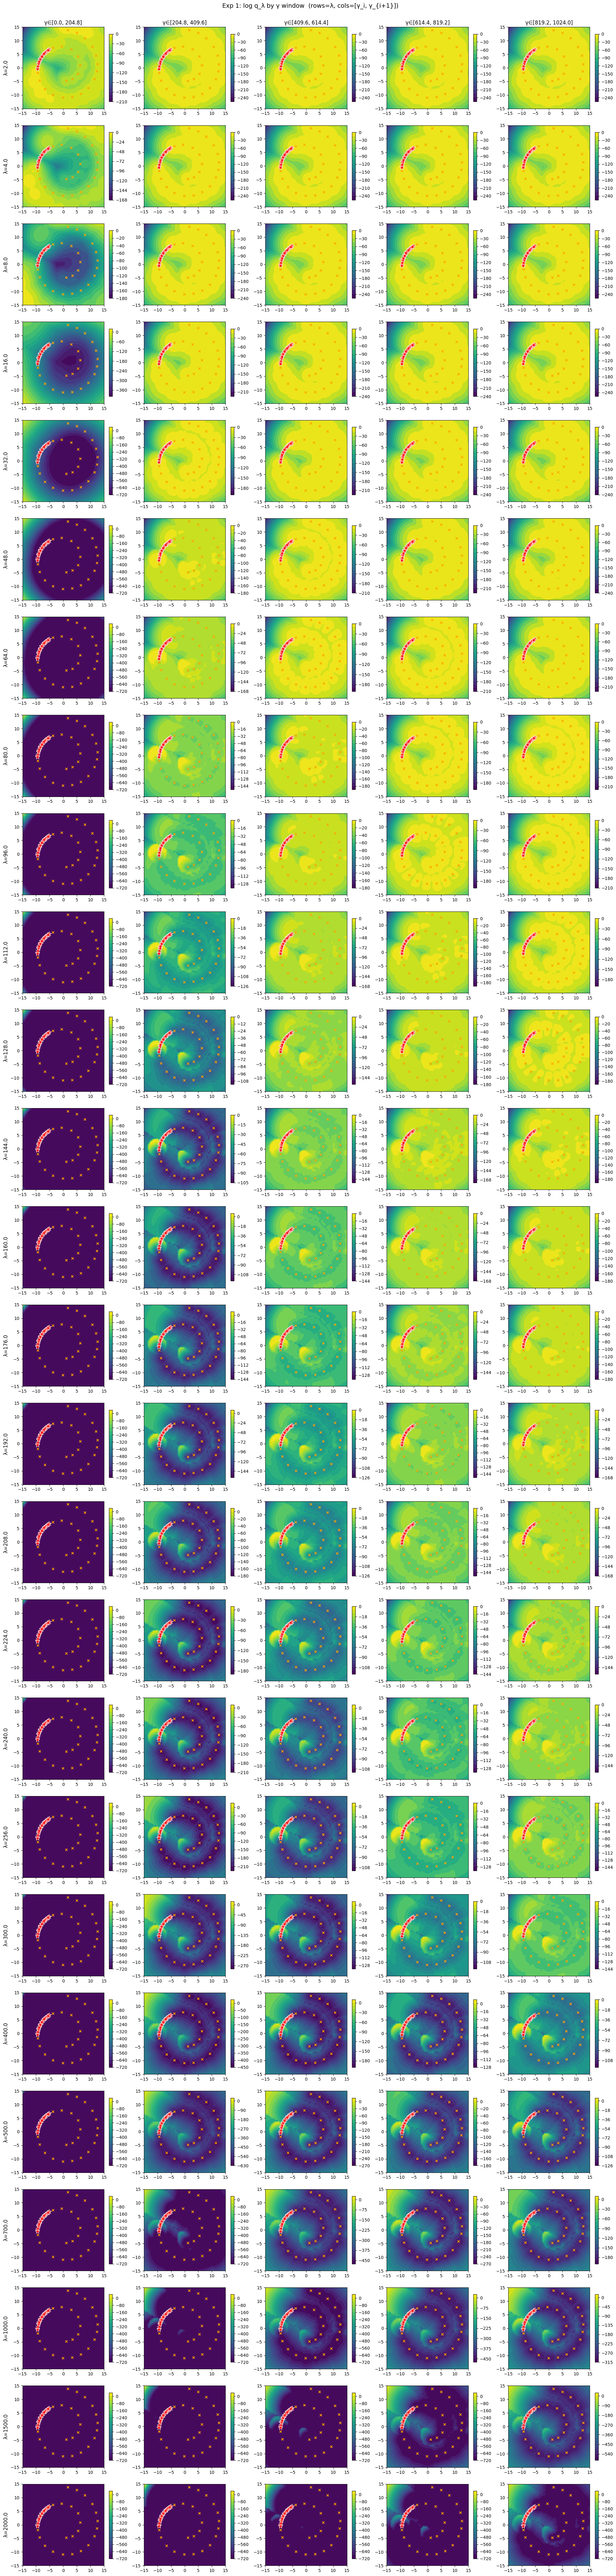

In [85]:
# Exp 1a (plot): 5x5 grid of log q_λ. rows = λ, cols = gamma sub-window.
EXP_LAMBDAS_1a = [2.0, 4.0, 8.0, 16.0, 32.0, 48.0, 64.0, 80.0, 96.0, 112.0, 128.0, 144.0, 160.0, 176.0, 192.0, 208.0, 224.0, 240.0, 256.0, 300.0, 400.0, 500.0, 700.0, 1000.0, 1500.0, 2000.0]
nrows, ncols = len(EXP_LAMBDAS_1a), len(exp1_expected_dists)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
for r, LAMBDA in enumerate(EXP_LAMBDAS_1a):
    for c in range(ncols):
        ax = axes[r, c]
        log_q, _, _ = grid_normalize(log_p_grid_roll2 + LAMBDA * exp1_expected_dists[c], cell_area)
        plot_field(log_q, XX, YY, ax=ax,
                   title=(exp1_labels[c] if r == 0 else ""),
                   marked=MEANS, missing=MISSING)
        if c == 0:
            ax.set_ylabel(f"λ={LAMBDA}", fontsize=12)
fig.suptitle("Exp 1: log q_λ by γ window  (rows=λ, cols=[γ_i, γ_{i+1}])", fontsize=14, y=1)
plt.tight_layout()
plt.show()

$\sigma = \frac{1}{\sqrt{\gamma}}$, so $\gamma = \frac{1}{\sigma^2}$. Hence:

low $\gamma$ <-> large $\sigma$ -> heavy blur.

high $\gamma$ <-> small $\sigma$ -> little noise.

**For small $\gamma$ values**, the noise floor $\gamma$ dominates the data term $\gamma^2 S^2$, the modes overlap, and the mixture collapses to a single Gaussian, whose score is linear:

$$\nabla\log p_{Y_\gamma}(y)=-\frac{y-\gamma\bar\mu}{\gamma^2 S^2+\gamma}.$$

For the blurred variance: $\mathrm{var}:=\gamma^2 S^2+\gamma$.
The IEM compares the score field at the noised images of $x_1$ and $x_2$ along the same Brownian path, therefore:

$$y_1=\gamma x_1+w_\gamma,\qquad y_2=\gamma x_2+w_\gamma,$$

$$s_1=-\frac{y_1-\gamma\bar\mu}{\mathrm{var}}=-\frac{\gamma x_1+w_\gamma-\gamma\bar\mu}{\mathrm{var}},\qquad s_2=-\frac{y_2-\gamma\bar\mu}{\mathrm{var}}=-\frac{\gamma x_2+w_\gamma-\gamma\bar\mu}{\mathrm{var}}.$$

$$s_1-s_2=-\frac{(\gamma x_1+w_\gamma-\gamma\bar\mu)-(\gamma x_2+w_\gamma-\gamma\bar\mu)}{\mathrm{var}}=-\frac{\gamma(x_1-x_2)}{\gamma^2 S^2+\gamma} = -\frac{x_1-x_2}{\gamma S^2+1}.$$

$$\lVert s_1-s_2\rVert^2=\frac{\lVert x_1-x_2\rVert^2}{(\gamma S^2+1)^2}.$$

- **Conclusion 1a**: When we take $\gamma\to0$, the denominator $\gamma S^2+1\to1$, so $\lVert s_1-s_2\rVert^2\xrightarrow{\ \gamma\to0\ }\lVert x_1-x_2\rVert^2$, the integrand reduces to plain squared Euclidean distance. Therefore, the density is just pushed away when increasing $\lambda$.


**In the opposite limit (large $\gamma$, small $\sigma$, little blur)** the noise floor is negligible, so $\mathrm{var}=\gamma^2 S^2+\gamma\to\gamma^2 S^2$. The modes stay separated, since $\frac{\gamma\lVert\mu_i-\mu_j\rVert}{\sqrt{\mathrm{var}}}\to\frac{\lVert\mu_i-\mu_j\rVert}{S}$ (a fixed nonzero separation), and $p$ keeps its full multimodal structure. The score is no longer linear, so the cancellation of 1a no longer applies: $\lVert s_1-s_2\rVert^2$ now depends on *where* $x_1,x_2$ sit relative to the modes, not just on $\lVert x_1-x_2\rVert$.

Concretely, as $\sigma\to0$ the noised observation $y=\gamma x+w_\gamma$ concentrates and the marginal score recovers the clean-data score up to the $\gamma$ scaling:

$$\nabla\log p_{Y_\gamma}(\gamma x+w_\gamma)\;\xrightarrow{\ \gamma\to\infty\ }\;\frac{1}{\gamma}\,\nabla\log p_X(x).$$

Taking the difference and squaring then gives:

$$s_1-s_2\;\longrightarrow\;\frac{1}{\gamma}\big(\nabla\log p_X(x_1)-\nabla\log p_X(x_2)\big),$$

$$\lVert s_1-s_2\rVert^2\;\longrightarrow\;\frac{1}{\gamma^2}\big\lVert\nabla\log p_X(x_1)-\nabla\log p_X(x_2)\big\rVert^2.$$

The integrand **factorizes** into a $\gamma$-dependent magnitude $\frac{1}{\gamma^2}$ and a $\gamma$-independent shape $\big\lVert\nabla\log p_X(x_1)-\nabla\log p_X(x_2)\big\rVert^2$.

- **Conclusion 1b (stable shape).** Carrying the factorization through the metric's square root,

  $$\mathrm{IEM}_{\text{window}}=\underbrace{\big\lVert\nabla\log p_X(x_1)-\nabla\log p_X(x_2)\big\rVert}_{\text{shape, }\gamma\text{-independent}}\cdot\;c_{\text{window}},\qquad c_{\text{window}}:=\sqrt{\int_{\text{window}}\frac{d\gamma}{\gamma^2}}.$$

  Every high-$\gamma$ window measures the *same* geometric field, scaled only by $c_{\text{window}}$, which shrinks as the window moves up. Since $\lambda$ only sets contrast, the geometry emerges when the product $\lambda\,c_{\text{window}}$ overcomes $\log p$, so higher windows (smaller $c_{\text{window}}$) need proportionally larger $\lambda$ to reach the same shared shape.

- **Conclusion 1c (geometry, not distance).** Unlike 1a, the surviving field $\big\lVert\nabla\log p_X(x_1)-\nabla\log p_X(x_2)\big\rVert$ is set by the *shape* of $p$, not by position: it is large between points the density treats as structurally different rather than between points that are merely far apart. The tilt $q_\lambda\propto p\,e^{\lambda f}$ therefore rewards novel, on-manifold regions (the hole in $p$) over distant off-manifold ones. The creativity behavior the measure is meant to exhibit, and the regime the coarse Euclidean window of 1a cannot reach.

- **Conclusion 1d (choosing the integration window in high-D).** 1a–1c say the low-$\gamma$ (= high-$\sigma$) region contributes only a Euclidean floor while the geometry lives at high $\gamma$ (low $\sigma$), so the window should start above the floor. The crossover is governed by the channel variance $\gamma^2\,\mathrm{Cov}+\gamma I$ switching from noise-dominated ($\gamma I$) to data-dominated, at $\gamma\sim\frac{1}{\sigma_{\text{data}}^2}$, or equivalently, in $\sigma$ units, at $\sigma\sim\sigma_{\text{data}}$.
  - **Outer bounds** come from the denoiser's valid range $\sigma\in[\sigma_{\min},\sigma_{\max}]$ (EDM defaults $[0.002,\,80]$, i.e. $\gamma\in[\,\frac{1}{\sigma_{\max}^2},\,\frac{1}{\sigma_{\min}^2}\,]\approx[\,1.6\times10^{-4},\ 2.5\times10^{5}\,]$). Outside it the learned score is invalid.
  - **Lower cut** drops the high-$\sigma$ floor: keep $\sigma < C\,\sigma_{\text{data}}$ for a small constant $C$, i.e. $\gamma_{\text{lo}} > \frac{1}{(C\,\sigma_{\text{data}})^2}$. Here $\sigma_{\text{data}}$ is the fixed data scale the denoiser was trained at, which is an explicit EDM hyperparameter (default $0.5$ for images scaled to $[-1,1]$), or the sample standard deviation of the data.

  Choosing in $\sigma$-space is natural because $\sigma$ is noise in data units and $\sigma_{\text{data}}$ is the scale EDM is built around: the preconditioner $c_{\text{skip}}=\frac{\sigma_{\text{data}}^2}{\sigma^2+\sigma_{\text{data}}^2}$ pivots at $\sigma_{\text{data}}$ (staying $\approx1$ for $\sigma\ll\sigma_{\text{data}}$ and $\approx0$ for $\sigma\gg\sigma_{\text{data}}$), marking the same noise-floor-vs-data crossover. With the floor removed, $\lambda$ becomes a clean contrast knob (1b) with no Euclidean blow-out to bound it from above.

- **Heuristic Suggestion 1e (choosing $\lambda$).** When initially choosing $\lambda$, consider the spread of the two competing terms in $\log q_\lambda=\log p+\lambda f$, and match them:
  $$\lambda_0 \sim \frac{\text{spread}(\log p)}{\text{spread}(f)}.$$
  In image space the data is extremely sparse. Measure spread only on the data itself: evaluate $\log p$ and $f$ on real samples (not the ambient grid), then take their std or a tight inter-quantile range:
  ```python
  # logp, f evaluated on real samples x_data, not a grid
  spread_logp = logp.std()   # or q(logp, 0.75) - q(logp, 0.25)
  spread_f    = f.std()
  lambda_0    = spread_logp / spread_f
  ```
  Since the floor is cut (1d), $\lambda$ is monotone-safe, so sweep $\{0.3,1,3,10,etc.\}\times\lambda_0$ and take the largest $\lambda$ whose samples stay on-manifold.

In [14]:
# Exp 1 summary: floor-cut window vs full window, swept at data-derived lambda_0.

# data scale S and floor cutoff gamma_lo (1d, C=2), all from the data
S = torch.sqrt(VARS).mean().item()    # per-component std (sets the 1a crossover), NOT X_kept.std()
C = 2.0
gamma_lo = 1.0 / (C * S) ** 2         # cut the high-sigma / low-gamma floor
N_GAMMA  = 50                         # log-spaced quadrature resolution

gammas_full = torch.logspace(-10, 10, N_GAMMA, base=2, dtype=dtype)
gammas_cut  = torch.logspace(math.log2(gamma_lo), 10, N_GAMMA, base=2, dtype=dtype)

D_full = GeneralizedGlobalIEMDistance(p_roll2, gammas_full, num_eps=EXP_NUM_EPS,
                                      f_type=IEMFType.IDENTITY)
D_cut  = GeneralizedGlobalIEMDistance(p_roll2, gammas_cut,  num_eps=EXP_NUM_EPS,
                                      f_type=IEMFType.IDENTITY)

f_full = expected_distance(D_full, grid_points_roll2, x_refs)   # (G,)
f_cut  = expected_distance(D_cut,  grid_points_roll2, x_refs)   # (G,)

# lambda_0 by scale-matching spreads on the cut window, measured on samples (1e)
# evaluate spread on x_refs (samples from p), not the ambient grid
f_cut_on_refs = expected_distance(D_cut, x_refs, x_refs)        # (R,)
logp_on_refs  = p_roll2.log_p_X(x_refs)                         # (R,)
lambda_0 = (logp_on_refs.std() / f_cut_on_refs.std()).item()

print(f"S (data std)   = {S:.3f}")
print(f"gamma_lo (C={C}) = {gamma_lo:.4g}   (sigma_cut = {C*S:.2f})")
print(f"lambda_0        = {lambda_0:.4g}")

S (data std)   = 0.681
gamma_lo (C=2.0) = 0.5389   (sigma_cut = 1.36)
lambda_0        = 3.871


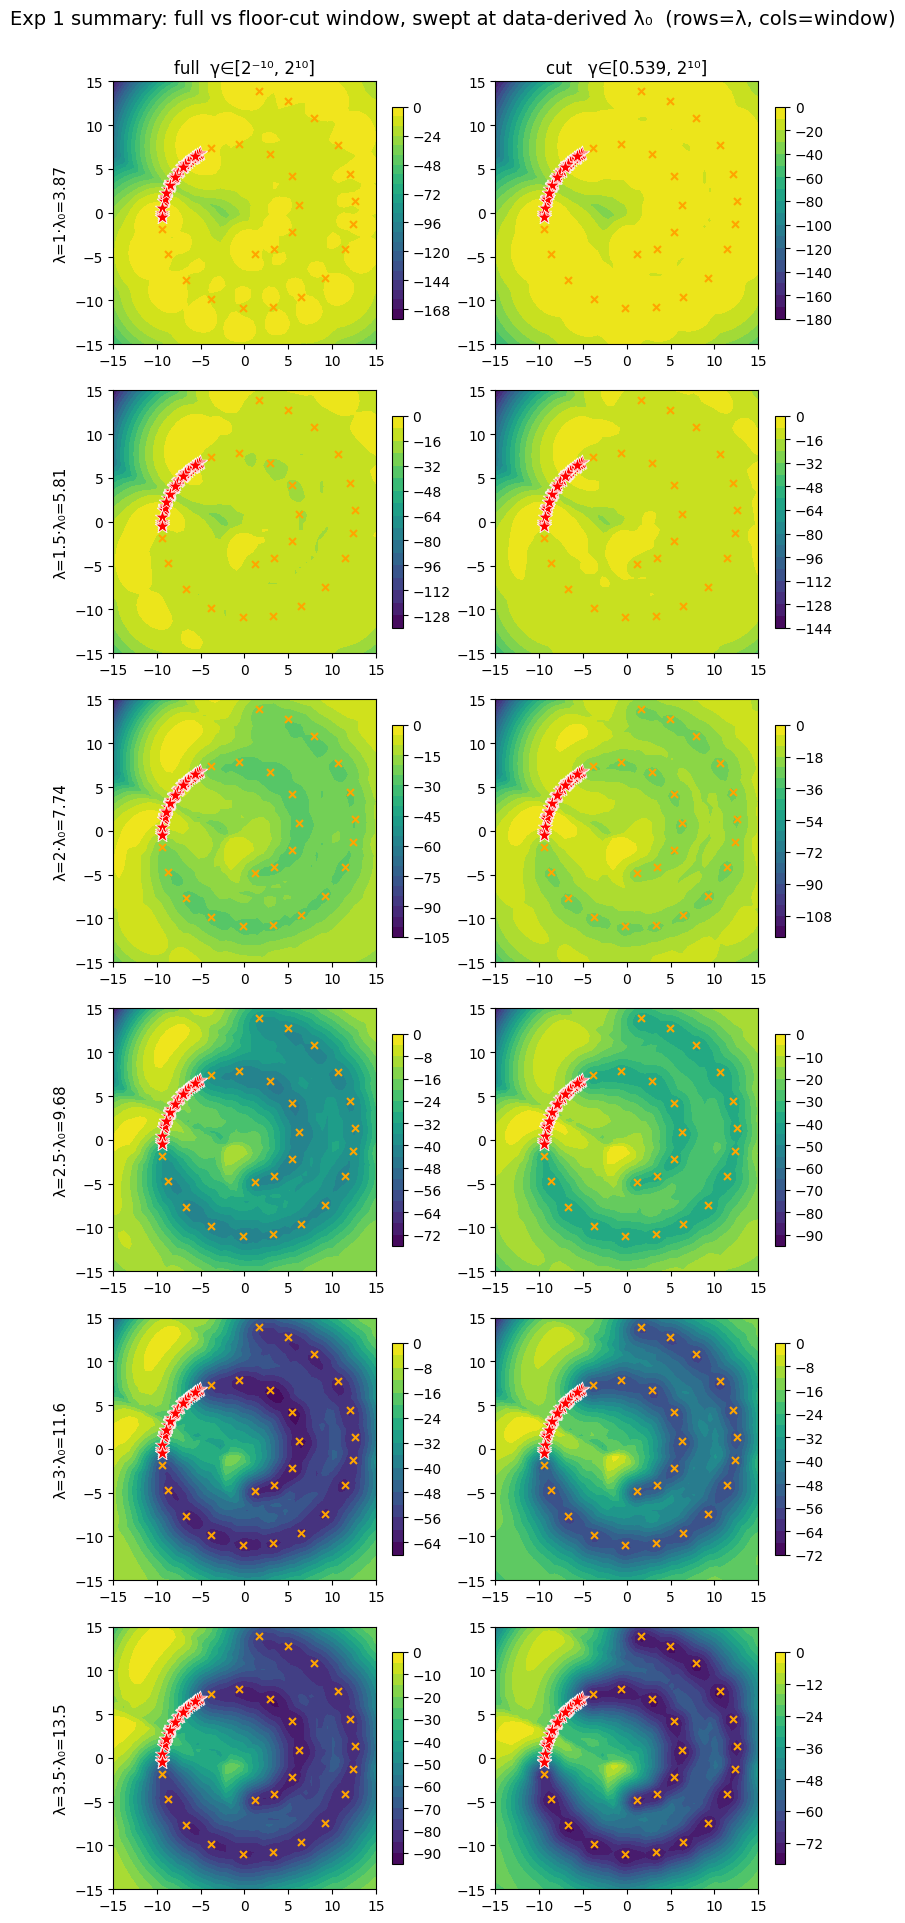

In [ ]:
# 3 x 2 grid: rows = {lambda_0, 3*lambda_0, 10*lambda_0}, cols = {full, cut}
lambda_mults = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
cols = [("full  γ∈[2⁻¹⁰, 2¹⁰]", f_full),
        (f"cut   γ∈[{gamma_lo:.3g}, 2¹⁰]", f_cut)]

fig, axes = plt.subplots(len(lambda_mults), len(cols), figsize=(4 * len(cols), 3.2 * len(lambda_mults)))
for r, m in enumerate(lambda_mults):
    lam = m * lambda_0
    for c, (label, f_vals) in enumerate(cols):
        ax = axes[r, c]
        log_q, _, _ = grid_normalize(log_p_grid_roll2 + lam * f_vals, cell_area)
        plot_field(log_q, XX, YY, ax=ax,
                   title=(label if r == 0 else ""),
                   marked=MEANS, missing=MISSING)
        if c == 0:
            ax.set_ylabel(f"λ={m:g}·λ₀={lam:.3g}", fontsize=11)
fig.suptitle("Exp 1 summary: full vs floor-cut window, swept at data-derived λ₀  "
             "(rows=λ, cols=window)", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

In [15]:
# Exp 1 summary (compute): floor-cut sweep over C, each window self-calibrated.
S = torch.sqrt(VARS).mean().item()             # per-component std (1a crossover scale)
N_GAMMA = 50

C_OPTIONS = [None, 2.0, 1.0, 0.75, 0.5]        # None = no cut (full window)
cut_results = []

for C in C_OPTIONS:
    if C is None:
        g_lo = 2.0 ** -10
        label = "no cut"
    else:
        g_lo = 1.0 / (C * S) ** 2
        label = f"C={C:g} (γ_lo={g_lo:.3g})"

    gammas = torch.logspace(math.log2(g_lo), 10, N_GAMMA, base=2, dtype=dtype)
    dist = GeneralizedGlobalIEMDistance(p_roll2, gammas, num_eps=EXP_NUM_EPS,
                                        f_type=IEMFType.IDENTITY)

    f_grid = expected_distance(dist, grid_points_roll2, x_refs)   # (G,)
    f_refs = expected_distance(dist, x_refs, x_refs)              # (R,)
    logp_refs = p_roll2.log_p_X(x_refs)                          # (R,)
    lam0 = (logp_refs.std() / f_refs.std()).item()

    cut_results.append({"label": label, "f": f_grid, "lam0": lam0})
    print(f"{label:22s} done   λ₀={lam0:.3g}")

print(f"\nS={S:.3f}, crossover γ≈1/S²={1/S**2:.3g}")

no cut                 done   λ₀=3.82
C=2 (γ_lo=0.539)       done   λ₀=3.87
C=1 (γ_lo=2.16)        done   λ₀=4.37
C=0.75 (γ_lo=3.83)     done   λ₀=5.01
C=0.5 (γ_lo=8.62)      done   λ₀=6.69

S=0.681, crossover γ≈1/S²=2.16


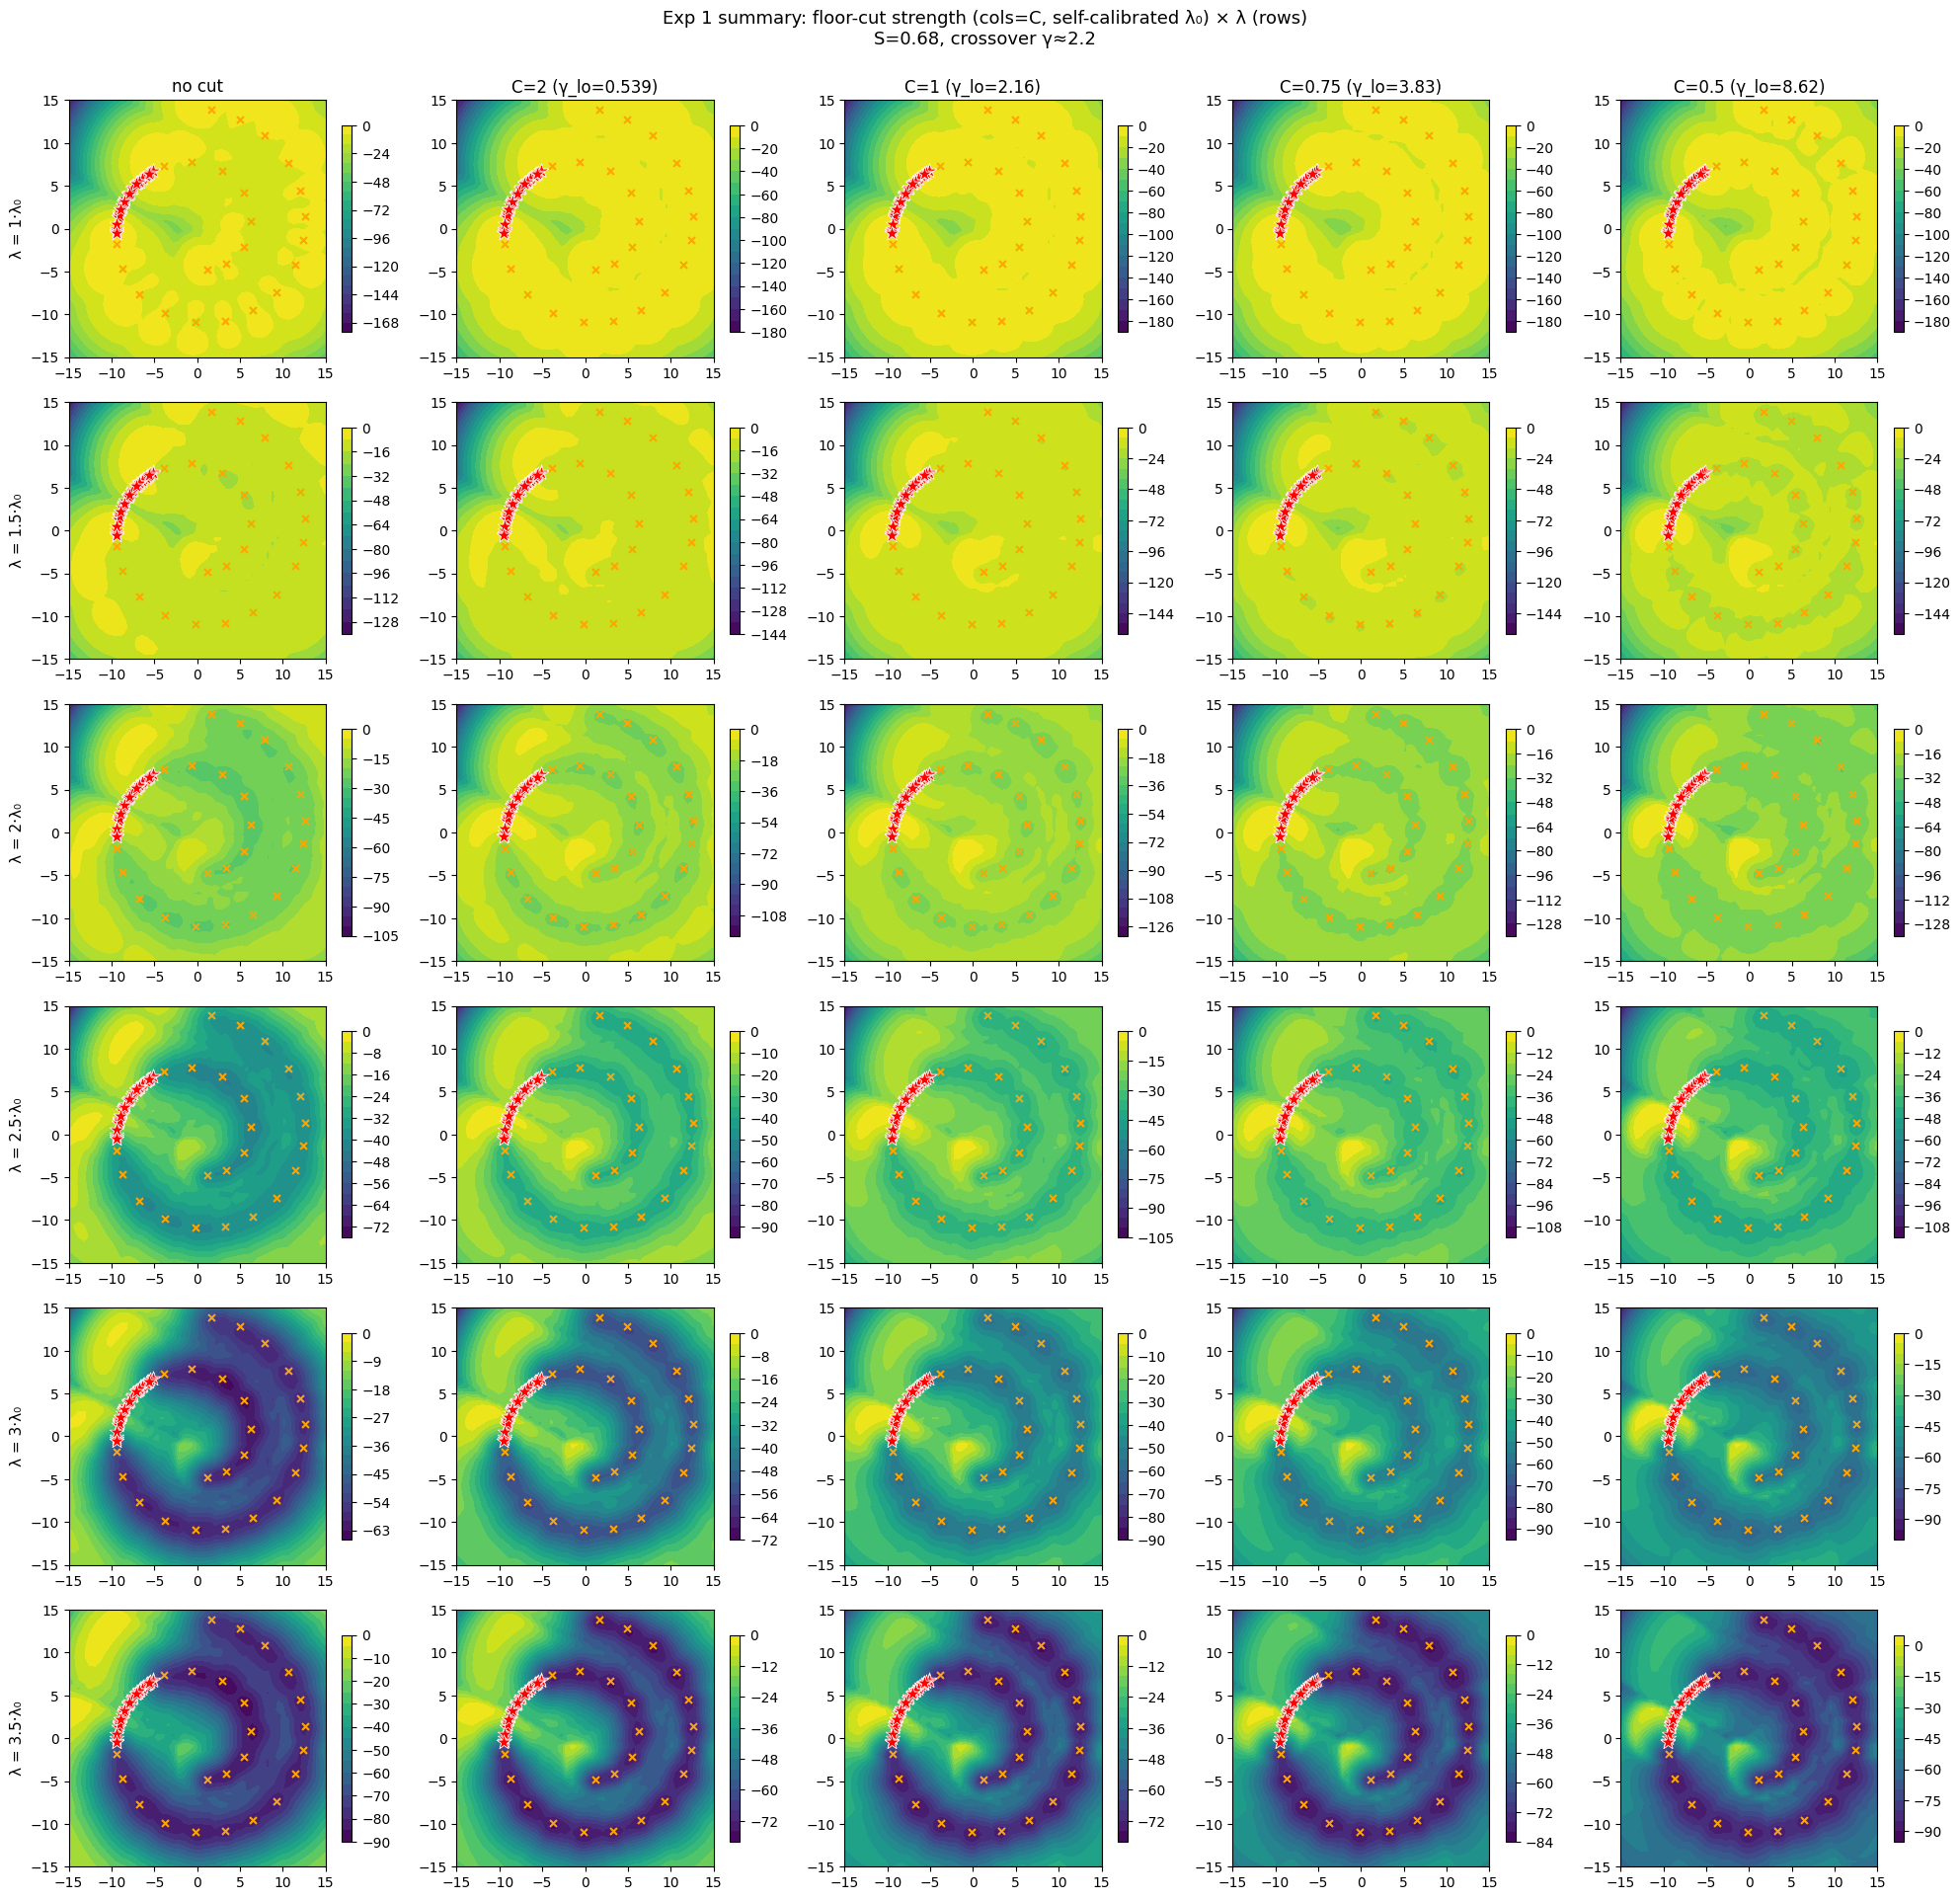

In [17]:
# Exp 1 summary (plot): rows = λ multiples (per-column λ₀), cols = C options.
lambda_mults = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
nrows, ncols = len(lambda_mults), len(cut_results)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
for r, m in enumerate(lambda_mults):
    for c, res in enumerate(cut_results):
        ax = axes[r, c]
        lam = m * res["lam0"]
        log_q, _, _ = grid_normalize(log_p_grid_roll2 + lam * res["f"], cell_area)
        plot_field(log_q, XX, YY, ax=ax,
                   title=(res["label"] if r == 0 else ""),
                   marked=MEANS, missing=MISSING)
        if c == 0:
            ax.set_ylabel(f"λ = {m:g}·λ₀", fontsize=11)
fig.suptitle("Exp 1 summary: floor-cut strength (cols=C, self-calibrated λ₀) × λ (rows)\n"
             f"S={S:.2f}, crossover γ≈{1/S**2:.2g}", fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

### Exp 2 — effect of integration density

Vary the number of γ grid points `N_γ` over the full window `[2^-10, 2^10]` with a constant
step: `{50, 100, 150, 200, 250}` (sparse → dense). Columns = `N_γ`, rows = λ. The fields
should converge as the integral is resolved more finely.

In [38]:
# Exp 2 (compute): one IEM distance per integration density (full gamma window).
EXP2_DENSITIES = [50, 100, 150, 200, 250]   # constant step of 50
exp2_expected_dists = []
for n in EXP2_DENSITIES:
    gammas_n = torch.logspace(-10, 10, n, base=2, dtype=dtype)
    D_n = GeneralizedGlobalIEMDistance(p_roll2, gammas_n, num_eps=EXP_NUM_EPS,
                                       f_type=IEMFType.IDENTITY)
    exp2_expected_dists.append(expected_distance(D_n, grid_points_roll2, x_refs))
    print(f"density N_γ={n} done")

density N_γ=50 done
density N_γ=100 done
density N_γ=150 done
density N_γ=200 done
density N_γ=250 done


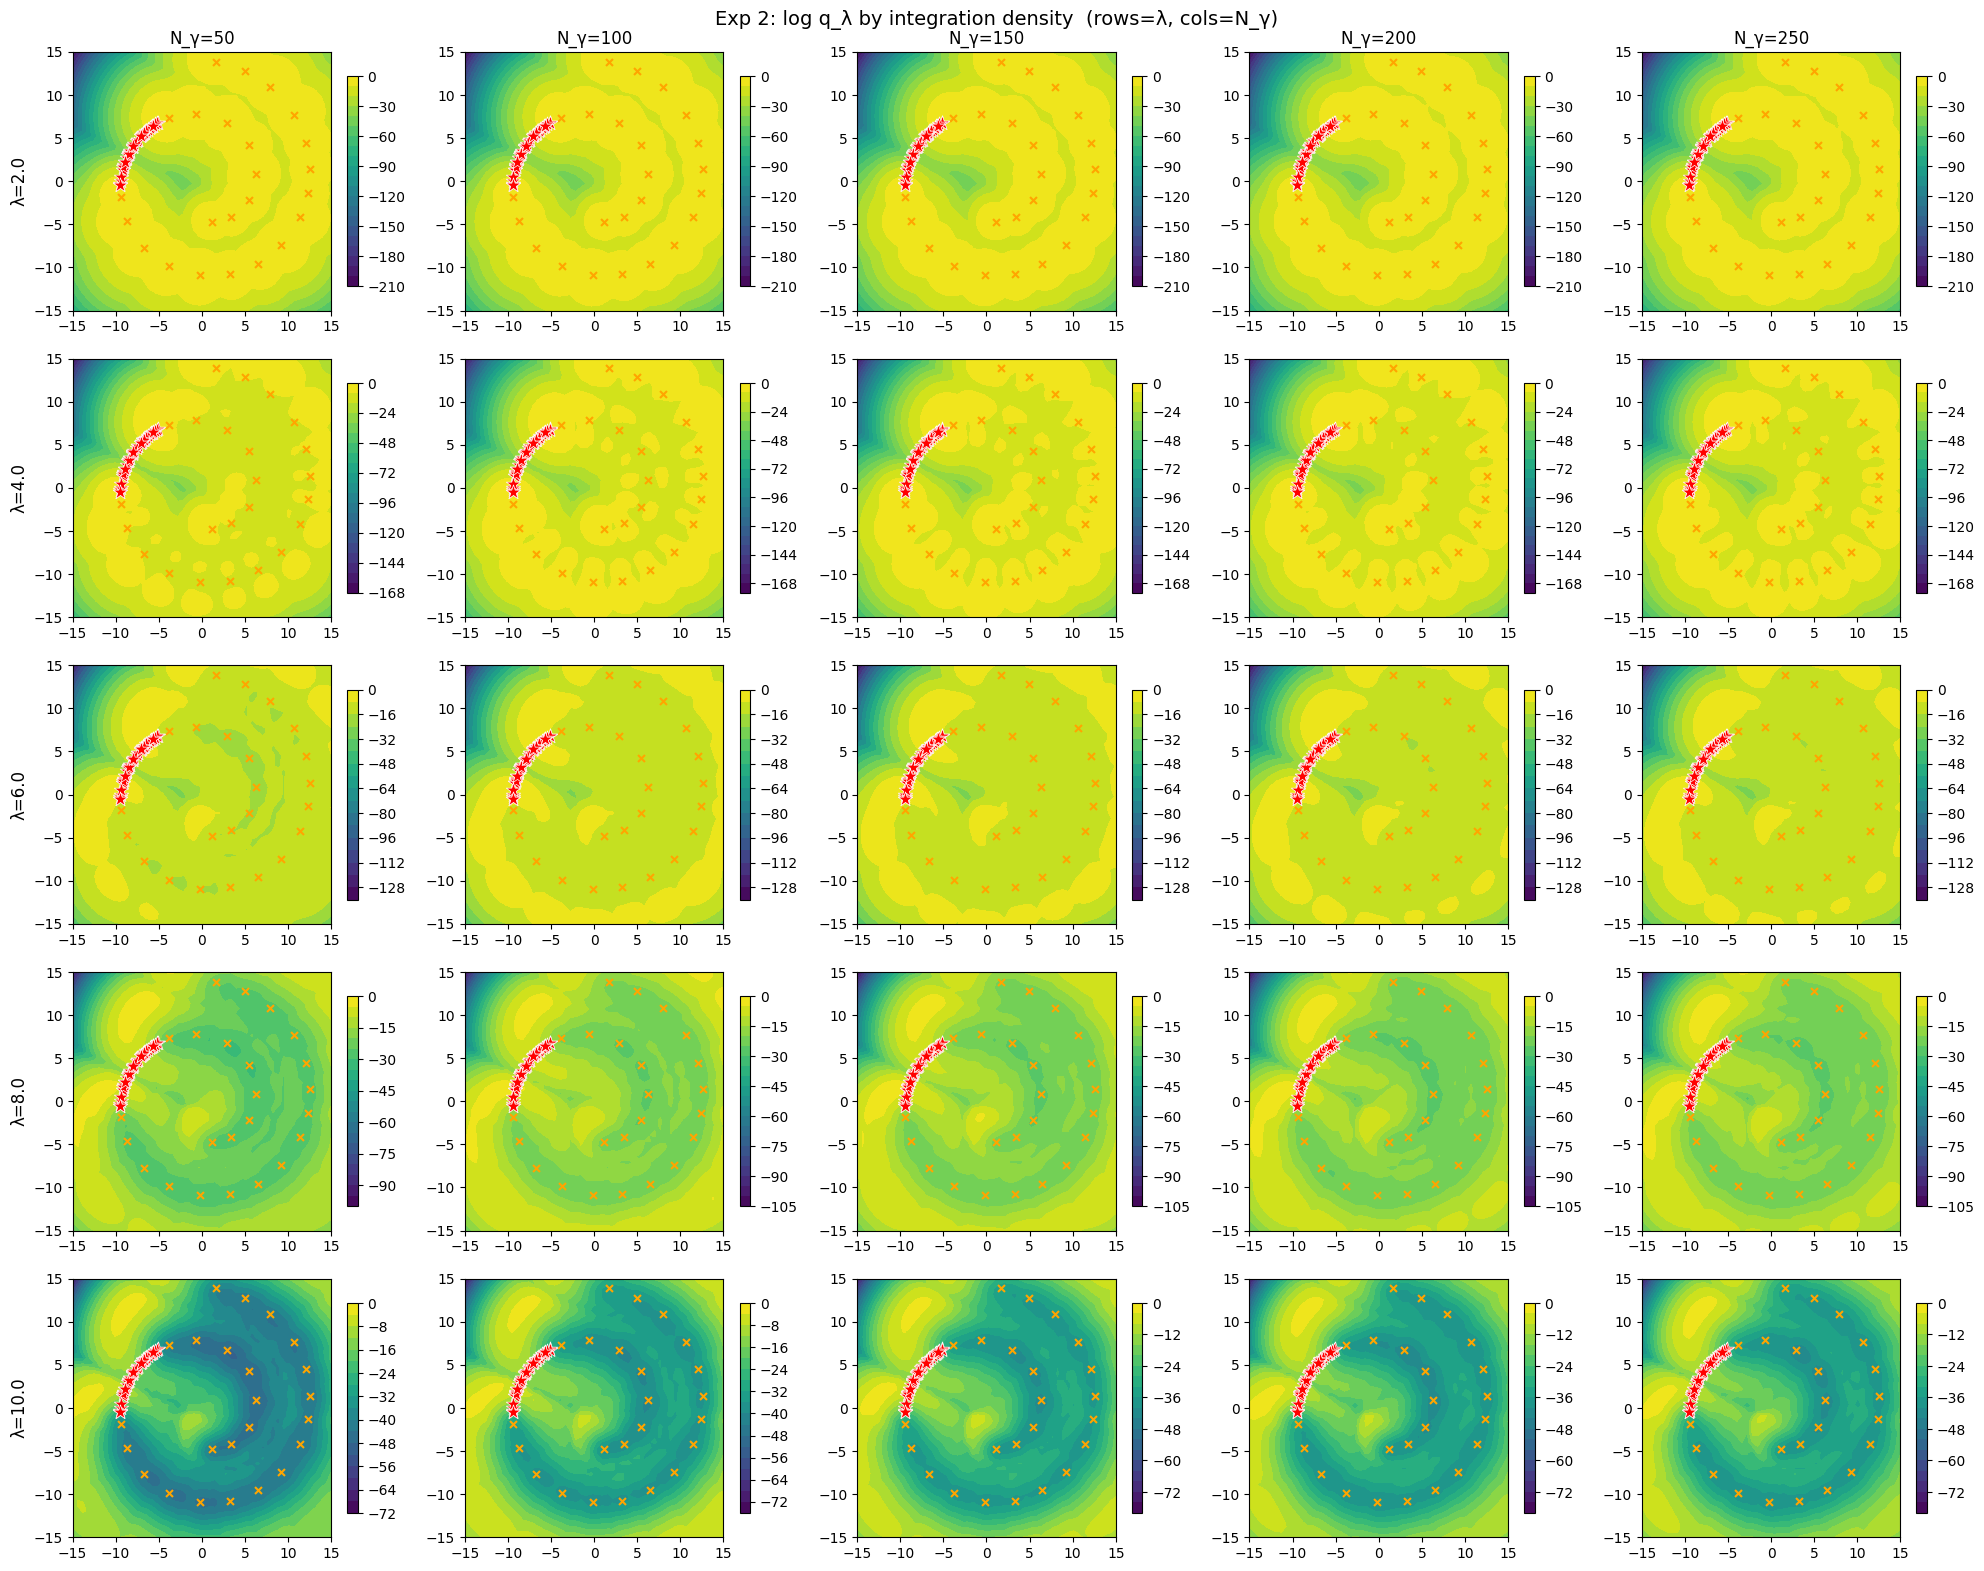

In [39]:
# Exp 2 (plot): 5x5 grid of log q_λ. rows = λ, cols = integration density N_γ.
nrows, ncols = len(EXP_LAMBDAS), len(exp2_expected_dists)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
for r, LAMBDA in enumerate(EXP_LAMBDAS):
    for c in range(ncols):
        ax = axes[r, c]
        log_q, _, _ = grid_normalize(log_p_grid_roll2 + LAMBDA * exp2_expected_dists[c], cell_area)
        plot_field(log_q, XX, YY, ax=ax,
                   title=(f"N_γ={EXP2_DENSITIES[c]}" if r == 0 else ""),
                   marked=MEANS, missing=MISSING)
        if c == 0:
            ax.set_ylabel(f"λ={LAMBDA}", fontsize=12)
fig.suptitle("Exp 2: log q_λ by integration density  (rows=λ, cols=N_γ)", fontsize=14)
plt.tight_layout(); plt.show()

### Exp 3 — effect of the number of x_refs

The creativity score is `E_{x'~p}[D_IEM(x', x)]` approximated as a mean over reference samples.
Vary the number of refs `R` with constant jumps: `{8, 16, 24, 32, 40}` (nested prefixes of one
40-ref draw). Columns = `R`, rows = λ. The estimate should stabilize as `R` grows.

In [40]:
# Exp 3 (compute): pairwise distance to the LARGEST ref set once, then nested prefix means.
EXP3_NREFS = [8, 16, 24, 32, 40]            # constant step of 8
GAMMAS_EXP = torch.logspace(-10, 10, 200, base=2, dtype=dtype)
x_refs_big = p_roll2.sample(max(EXP3_NREFS), seed=123)              # (40, 2)
D_exp3 = GeneralizedGlobalIEMDistance(p_roll2, GAMMAS_EXP, num_eps=EXP_NUM_EPS,
                                      f_type=IEMFType.IDENTITY)
pairwise_big = D_exp3.pairwise(grid_points_roll2, x_refs_big)       # (G, 40), computed once
exp3_expected_dists = [pairwise_big[:, :n].mean(dim=1) for n in EXP3_NREFS]
print(f"pairwise to {max(EXP3_NREFS)} refs done; ref counts: {EXP3_NREFS}")

pairwise to 40 refs done; ref counts: [8, 16, 24, 32, 40]


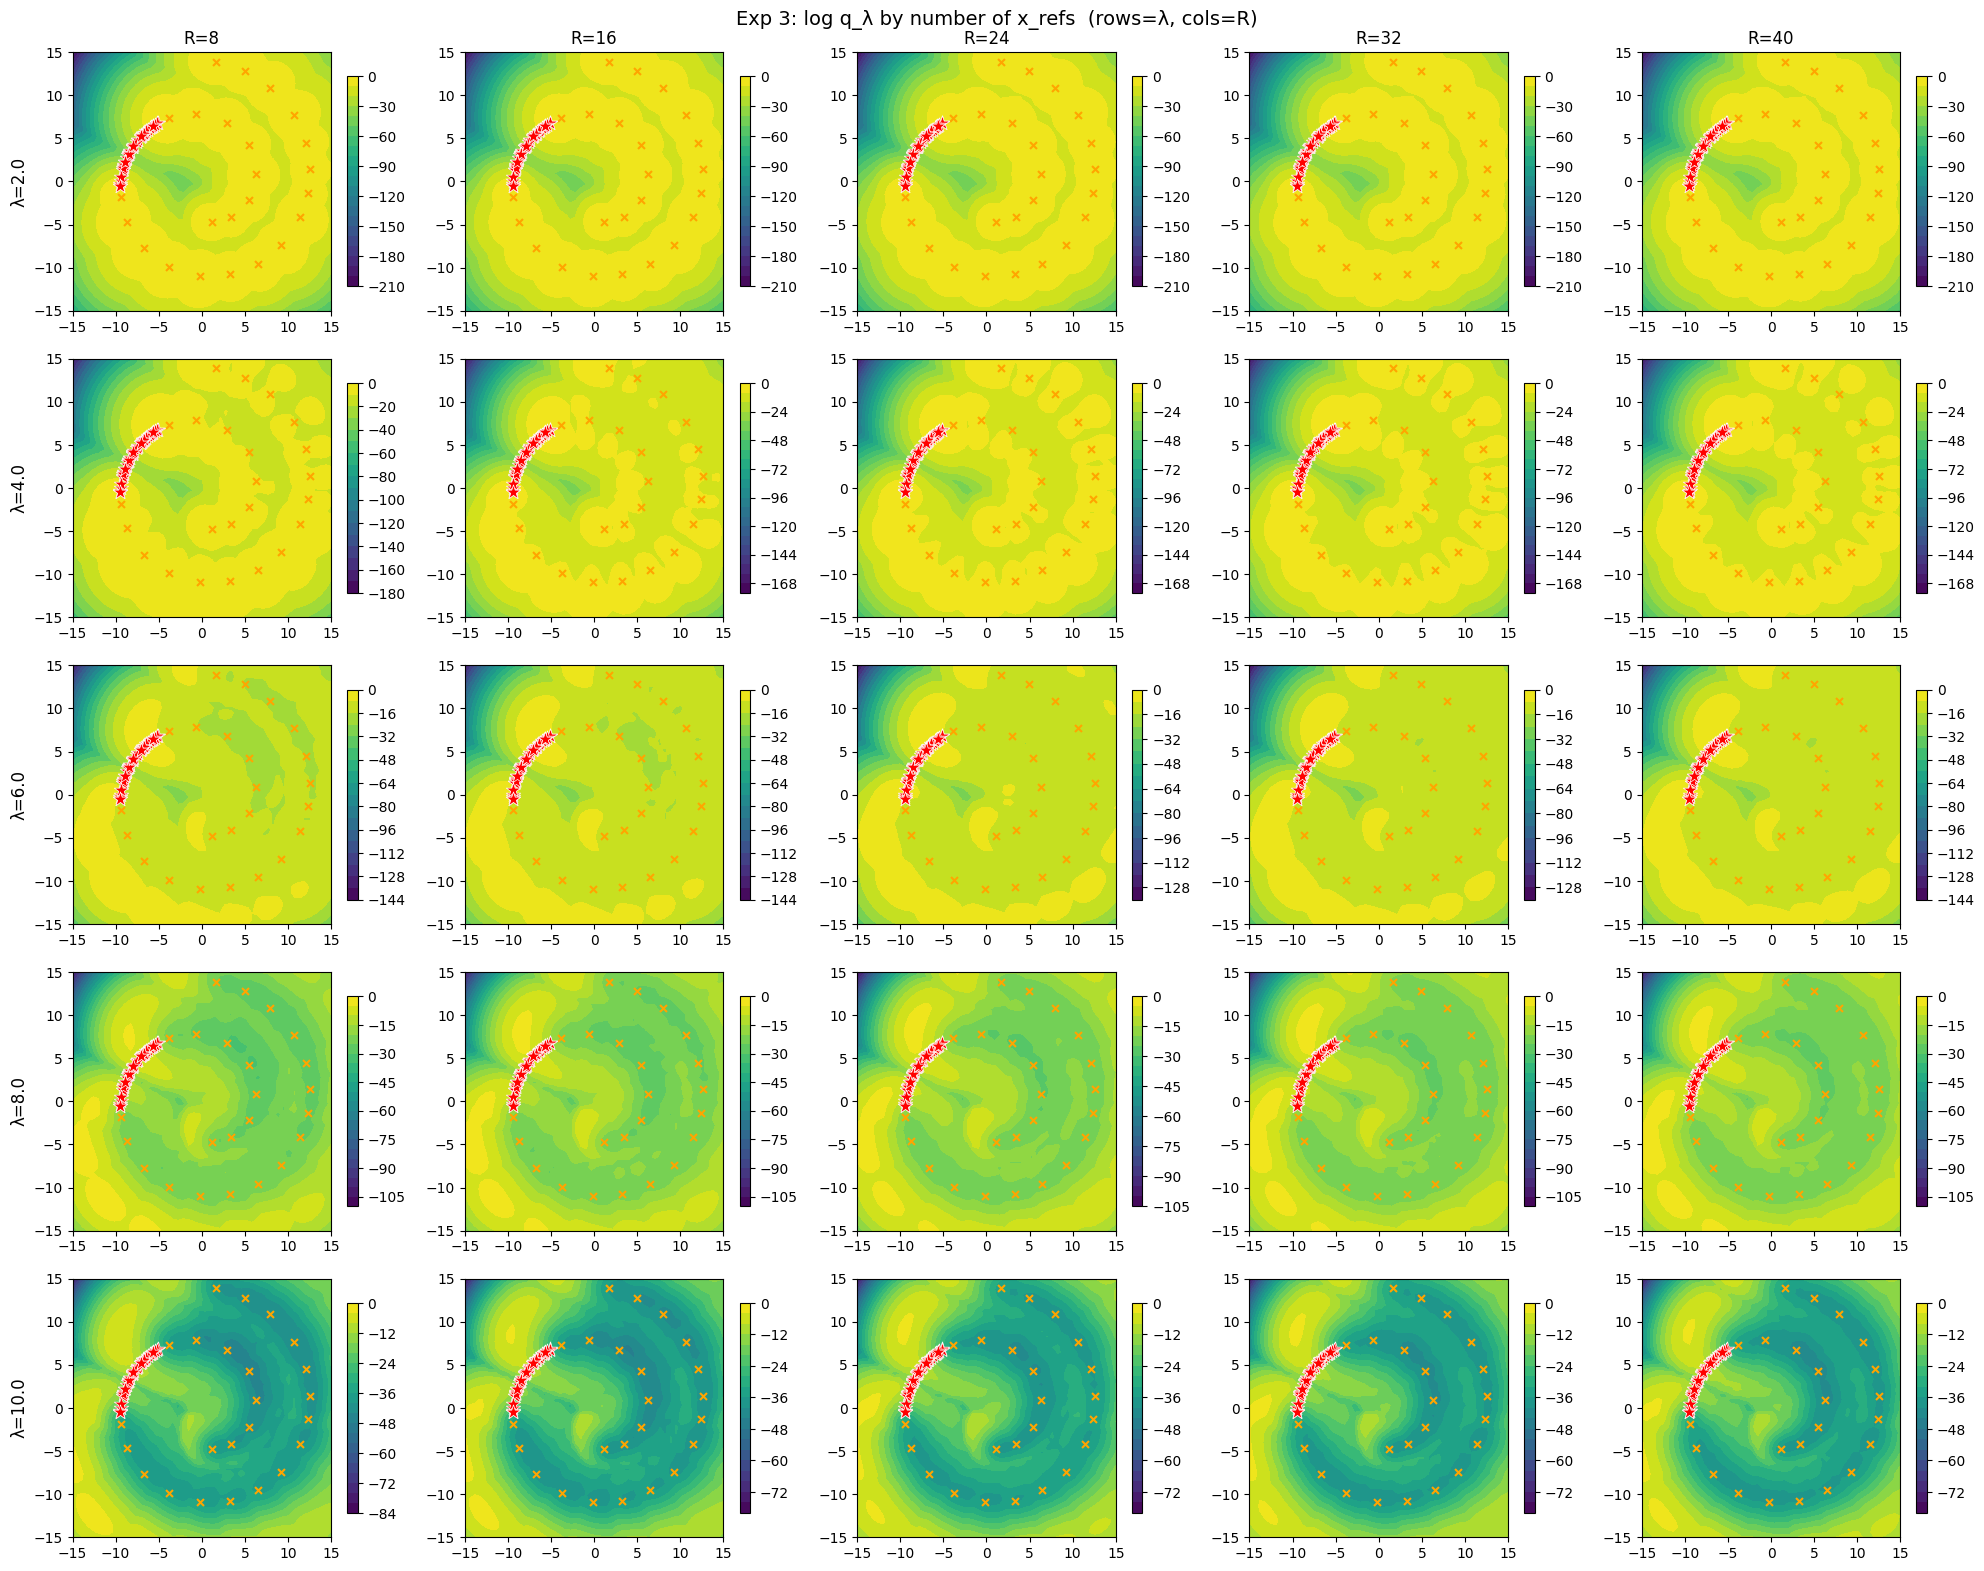

In [41]:
# Exp 3 (plot): 5x5 grid of log q_λ. rows = λ, cols = number of refs R.
nrows, ncols = len(EXP_LAMBDAS), len(exp3_expected_dists)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
for r, LAMBDA in enumerate(EXP_LAMBDAS):
    for c in range(ncols):
        ax = axes[r, c]
        log_q, _, _ = grid_normalize(log_p_grid_roll2 + LAMBDA * exp3_expected_dists[c], cell_area)
        plot_field(log_q, XX, YY, ax=ax,
                   title=(f"R={EXP3_NREFS[c]}" if r == 0 else ""),
                   marked=MEANS, missing=MISSING)
        if c == 0:
            ax.set_ylabel(f"λ={LAMBDA}", fontsize=12)
fig.suptitle("Exp 3: log q_λ by number of x_refs  (rows=λ, cols=R)", fontsize=14)
plt.tight_layout(); plt.show()

### Exp 4 — effect of f (identity vs squared)

The generalized IEM integrand carries `f'(α·Z)²`. With `f = identity` (`f' ≡ 1`) this is the
plain IEM; with `f = squared` (`f' = 2z`) it reweights by the log-likelihood-ratio process `Z`.
2×5 grid: columns = `{identity, squared}`, rows = λ.

In [42]:
# Exp 4 (compute): one IEM distance per f choice (full gamma window).
GAMMAS_EXP = torch.logspace(-10, 10, 200, base=2, dtype=dtype)
EXP4_FTYPES = [IEMFType.IDENTITY, IEMFType.SQUARED]
exp4_expected_dists, exp4_labels = [], []
for f_type in EXP4_FTYPES:
    D_f = GeneralizedGlobalIEMDistance(p_roll2, GAMMAS_EXP, num_eps=EXP_NUM_EPS, f_type=f_type)
    exp4_expected_dists.append(expected_distance(D_f, grid_points_roll2, x_refs))
    exp4_labels.append(f"f={f_type.value.entry_name}")
    print(f"{exp4_labels[-1]} done")

f=identity done
f=squared done


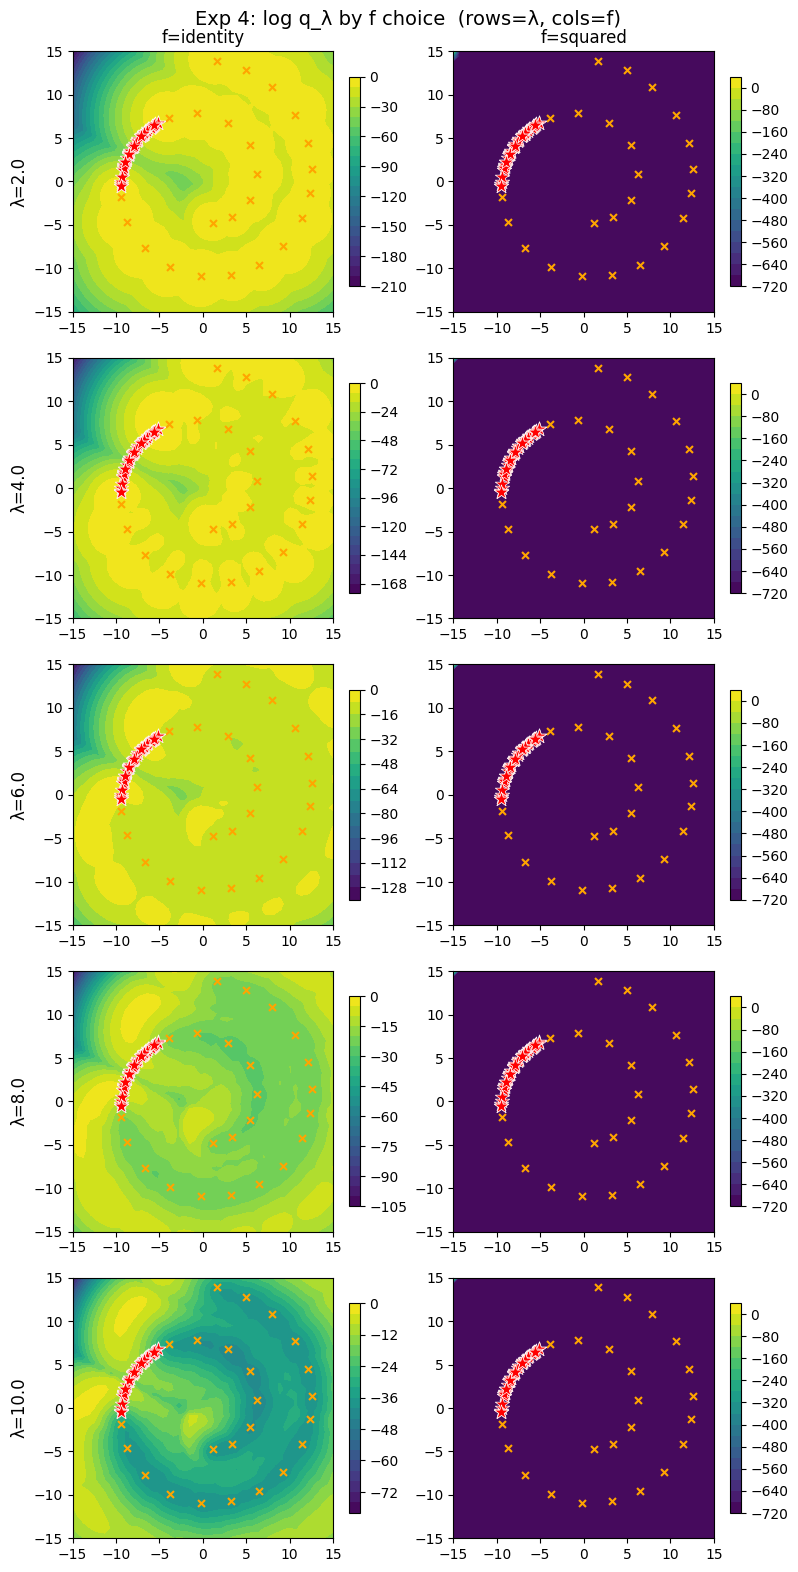

In [43]:
# Exp 4 (plot): 5x2 grid of log q_λ. rows = λ, cols = f (identity, squared).
nrows, ncols = len(EXP_LAMBDAS), len(exp4_expected_dists)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
for r, LAMBDA in enumerate(EXP_LAMBDAS):
    for c in range(ncols):
        ax = axes[r, c]
        log_q, _, _ = grid_normalize(log_p_grid_roll2 + LAMBDA * exp4_expected_dists[c], cell_area)
        plot_field(log_q, XX, YY, ax=ax,
                   title=(exp4_labels[c] if r == 0 else ""),
                   marked=MEANS, missing=MISSING)
        if c == 0:
            ax.set_ylabel(f"λ={LAMBDA}", fontsize=12)
fig.suptitle("Exp 4: log q_λ by f choice  (rows=λ, cols=f)", fontsize=14)
plt.tight_layout(); plt.show()

#### Finding: `f=squared` gives an improper tilt

With `λ ∈ {2,…,10}` the squared column above is blank: the tilted density is ~0 over the
plotted (data) region and all its mass sits at the window boundary. This is **not a plotting
artifact** — the squared-`f` creativity tilt is **non-normalizable** for this density.

Why: write `log q_λ(x) = log p(x) + λ·D(x)` and let `r` be the distance off the data manifold.
- Gaussian tails make `log p(x)` decay like **−r²**.
- Empirically (measured on this grid) `D(x)` grows like `r^{1.1}` for **identity** but `r^{3.2}` for **squared**
  (the integrand carries `f'(αZ)² = (2αZ)²`, and the log-ratio process `Z` itself grows ~quadratically in `r`).

So `log q_λ ∝ λ·r^{3.2} − r²`:
- **identity** (power 1 < 2): decay wins → proper density, finite peak at radius `r* ≈ λσ²`
  that merely slides outward as λ grows (peak at −9.5 → −11.3 → −13.2 for λ=2,6,10, still in-window).
- **squared** (power 3 > 2): the tilt wins → `log q_λ → +∞` as `r → ∞`. The density is improper
  for **any** `λ > 0`; mass escapes to infinity and `grid_normalize` piles it onto the boundary cell,
  leaving the interior at the `1e-300` floor. Enlarging the window only pushes the pile farther out.

This is itself the answer to "how does `f` affect the measure": `identity` yields a well-defined
creativity-tilted distribution, while `squared` does not (for a Gaussian-tailed target).

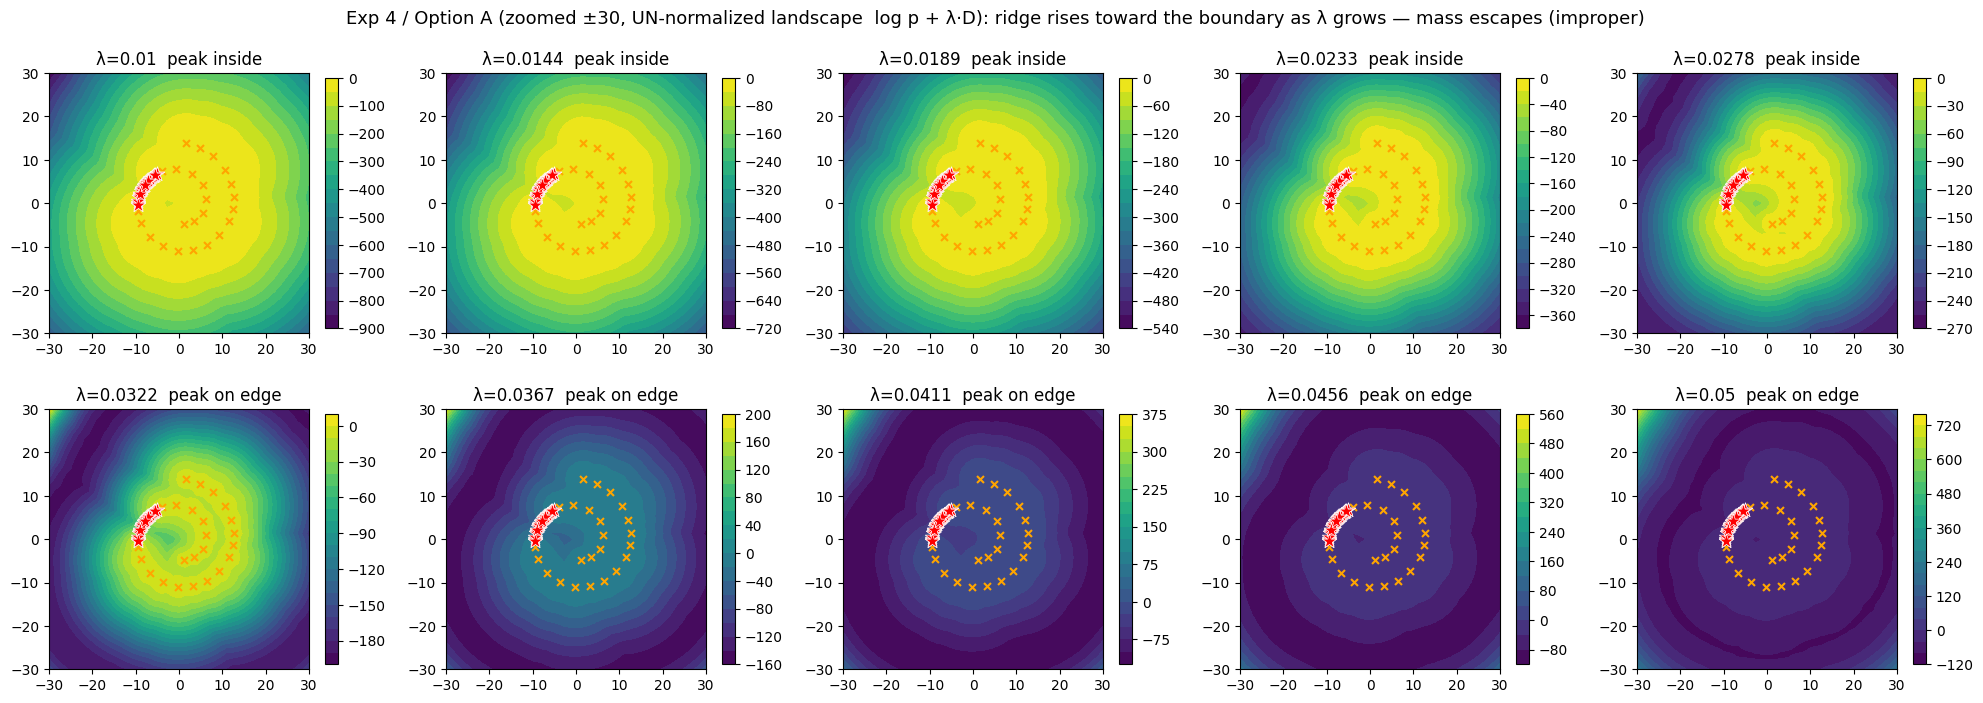

In [55]:
# Option A (zoomed out): to SEE where the squared-f mass goes we must evaluate the tilt on a larger
# [-30, 30] grid (contourf can't show values that were never computed; log_p is free anywhere but the
# tilt term D is the IEM integral and only exists where we run it). Coarse settings -> rough but fast.
#
# We plot the UN-normalized tilt landscape  log p + λ·D  (NOT grid_normalize): the squared-f tilt is
# improper, so the normalizer Z is meaningless and its 1e-300 underflow clamp would crush everything
# to a dark floor with a single corner spike. The raw landscape instead shows the true shape:
# λ=0.02 peaks on the data, but for λ ≳ 0.06 the surface rises monotonically toward the boundary
# (no interior maximum) — mass escapes outward, and lowering λ only delays it.
ZOOM = 30.0
zgrid, zXX, zYY, zcell = make_grid((-ZOOM, ZOOM), (-ZOOM, ZOOM), grid_n=45, dtype=dtype)
zlog_p = p_roll2.log_p_X(zgrid)
gammas_zoom = torch.logspace(-10, 10, 120, base=2, dtype=dtype)
D_sq_zoom = GeneralizedGlobalIEMDistance(p_roll2, gammas_zoom, num_eps=8, f_type=IEMFType.SQUARED)
d_sq_zoom = expected_distance(D_sq_zoom, zgrid, x_refs[:16])

SMALL_LAMBDAS = torch.linspace(0.01, 0.05, 10).tolist()   # 10 equal-spaced λ, 2x5 grid
nrows, ncols = 2, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.6 * nrows))
axes = axes.flatten()
for c, LAMBDA in enumerate(SMALL_LAMBDAS):
    log_q_unnorm = zlog_p + LAMBDA * d_sq_zoom           # un-normalized tilt landscape
    peak = zgrid[log_q_unnorm.argmax()].tolist()
    on_edge = (abs(peak[0]) > ZOOM - 1.5) or (abs(peak[1]) > ZOOM - 1.5)
    plot_field(log_q_unnorm, zXX, zYY, ax=axes[c],
               title=f"λ={LAMBDA:.3g}  peak {'on edge' if on_edge else 'inside'}",
               marked=MEANS, missing=MISSING)
fig.suptitle("Exp 4 / Option A (zoomed ±30, UN-normalized landscape  log p + λ·D): "
             "ridge rises toward the boundary as λ grows — mass escapes (improper)",
             fontsize=13)
plt.tight_layout(); plt.show()